# Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
drugs = pd.read_csv('drugs.csv')

 # Can medicines be grouped by patterns of missing regulatory data that reflect different approval eras or regulatory contexts?

Motivation from EDA: Missingness is structured rather than random, with consistent sparsity patterns across subsets of drugs.

Who Benefits: Regulatory agencies can see indications of systematic documentation gaps and assess how data completeness has evolved over time.


## Preprocessing

In [ ]:
drugs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   category                                     1988 non-null   object 
 1   medicine_name                                1988 non-null   object 
 2   therapeutic_area                             1703 non-null   object 
 3   common_name                                  1984 non-null   object 
 4   active_substance                             1987 non-null   object 
 5   product_number                               1988 non-null   int64  
 6   patient_safety                               1988 non-null   bool   
 7   authorisation_status                         1987 non-null   object 
 8   atc_code                                     1960 non-null   object 
 9   additional_monitoring                        1988 non-null   bool   
 10  

In [ ]:
drugs['decision_date'] = pd.to_datetime(drugs['decision_date'], errors='coerce')
drugs['approval_year'] = drugs['decision_date'].dt.year
drugs_approved_per_year = drugs['approval_year'].value_counts().sort_index()
display(drugs_approved_per_year.tail(10))

,count
approval_year,
2014.0,31
2015.0,30
2016.0,33
2017.0,37
2018.0,54
2019.0,59
2020.0,100
2021.0,381
2022.0,794


In [ ]:
drugs.head(5)

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url,approval_year
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2022.0
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0


## Prepare Missingness Data

Create a new DataFrame that indicates the presence (0) or absence (1) of data for relevant regulatory columns in the `drugs` DataFrame. This will transform the dataset into a format suitable for clustering based on missingness patterns.


In [ ]:
missing_cols = drugs.columns[drugs.isnull().any()].tolist()

missingness_df = drugs[missing_cols].isnull().astype(int)
display(missingness_df.head())
display(missingness_df.tail())

,therapeutic_area,common_name,active_substance,authorisation_status,atc_code,marketing_authorisation_date,date_of_refusal_of_marketing_authorisation,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,revision_date,approval_year
0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


,therapeutic_area,common_name,active_substance,authorisation_status,atc_code,marketing_authorisation_date,date_of_refusal_of_marketing_authorisation,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,revision_date,approval_year
1983,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1984,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1985,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1986,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1987,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0


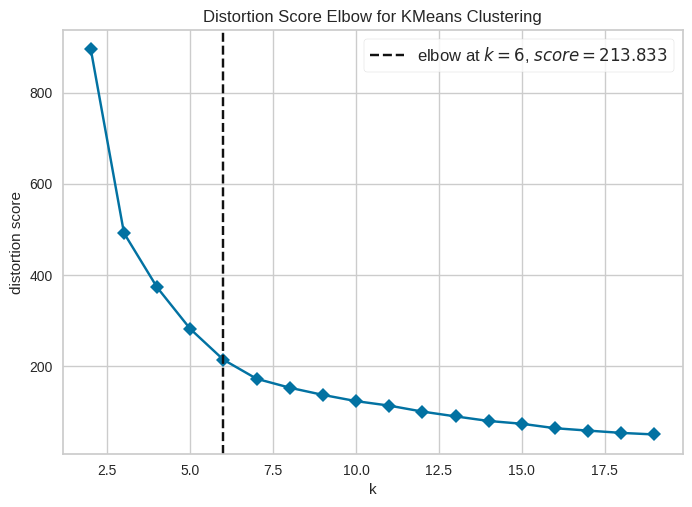

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

clustering = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(
    clustering, k=(2, 20), metric='distortion', timings=False, random_state=42
)

visualizer.fit(missingness_df)
visualizer.show()

## Added a Silhouette Score - M4

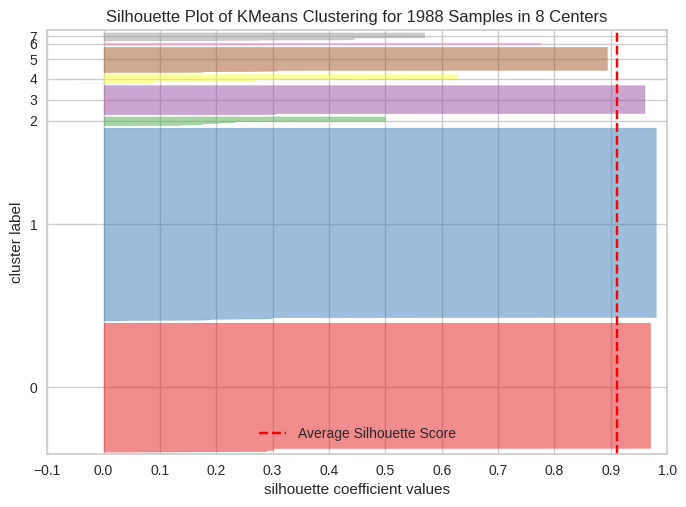

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1988 Samples in 8 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer

# Initialize a KMeans clustering estimator
clustering = KMeans(random_state=42, n_init=10)

# Pass the KMeans estimator to SilhouetteVisualizer
visualizer = SilhouetteVisualizer(
    clustering, k=(2, 20), metric='euclidean', timings=False
)

visualizer.fit(missingness_df)
visualizer.show()

## K-Means Clustering

K-Means on missingness data using the optimal number of clusters identified. Assign labels back to the original `drugs` DataFrame to group medicines by their missing data patterns.



Initialize a KMeans model with 3 clusters, fit it to the `missingness_df` to cluster medicines based on their missing data patterns, and then assign the resulting cluster labels to a new column in the original `drugs` DataFrame.



In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
missingness_clusters = kmeans.fit_predict(missingness_df)
drugs['missingness_cluster_kmean'] = missingness_clusters
display(drugs.head())

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url,approval_year,missingness_cluster_kmean
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2022.0,2
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,2
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,2
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,2
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...,2023.0,2


In [ ]:
drugs['decision_date'] = pd.to_datetime(drugs['decision_date'], errors='coerce')
drugs['approval_year'] = drugs['decision_date'].dt.year

In [ ]:
avg_approval_year_per_cluster = drugs.groupby('missingness_cluster_kmean')['approval_year'].mean()

missingness_df['missingness_cluster_kmean'] = drugs['missingness_cluster_kmean']
mean_missingness_per_cluster = missingness_df.groupby('missingness_cluster_kmean').mean()

print("\nAverage Approval Year per Cluster:")
print(avg_approval_year_per_cluster)

print("\nMean Missingness Percentage per Cluster for each Regulatory Column:")
print(mean_missingness_per_cluster)


Average Approval Year per Cluster:
missingness_cluster_kmean
0    2018.028346
1    2020.261905
2    2021.801811
3    2017.902098
4            NaN
5    2012.755556
Name: approval_year, dtype: float64

Mean Missingness Percentage per Cluster for each Regulatory Column:
                           therapeutic_area  common_name  active_substance  \
missingness_cluster_kmean                                                    
0                                  0.001575     0.001575          0.000000   
1                                  1.000000     0.007937          0.000000   
2                                  0.003018     0.000000          0.000000   
3                                  1.000000     0.006993          0.000000   
4                                  0.244444     0.022222          0.022222   
5                                  0.022222     0.000000          0.000000   

                           authorisation_status  atc_code  \
missingness_cluster_kmean                    

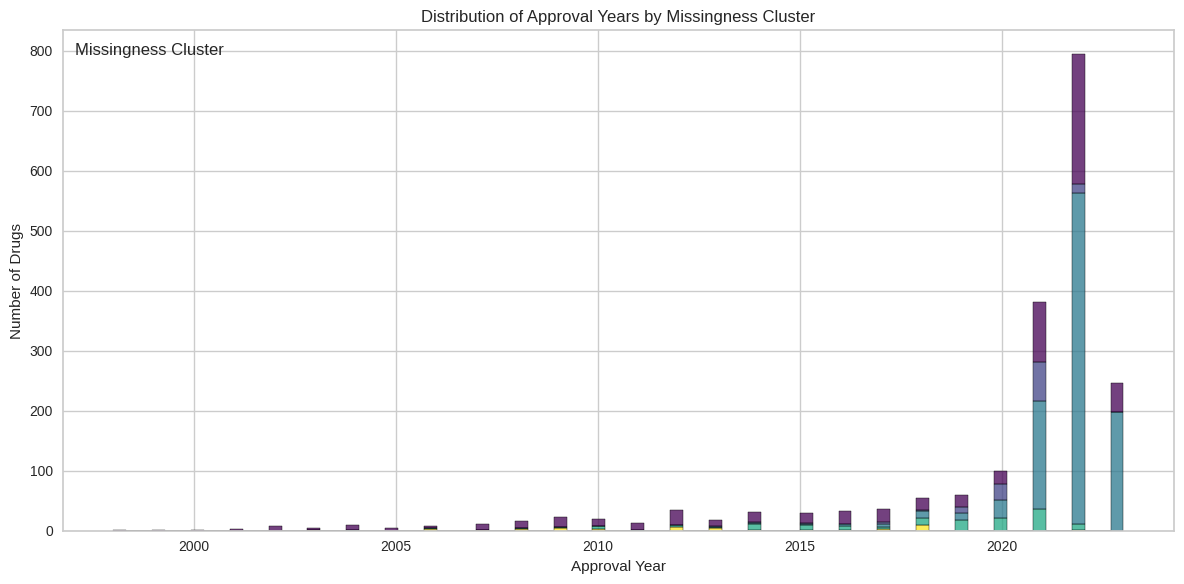

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=drugs, x='approval_year', hue='missingness_cluster_kmean', multiple='stack', palette='viridis', kde=False)
plt.title('Distribution of Approval Years by Missingness Cluster')
plt.xlabel('Approval Year')
plt.ylabel('Number of Drugs')
plt.legend(title='Missingness Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

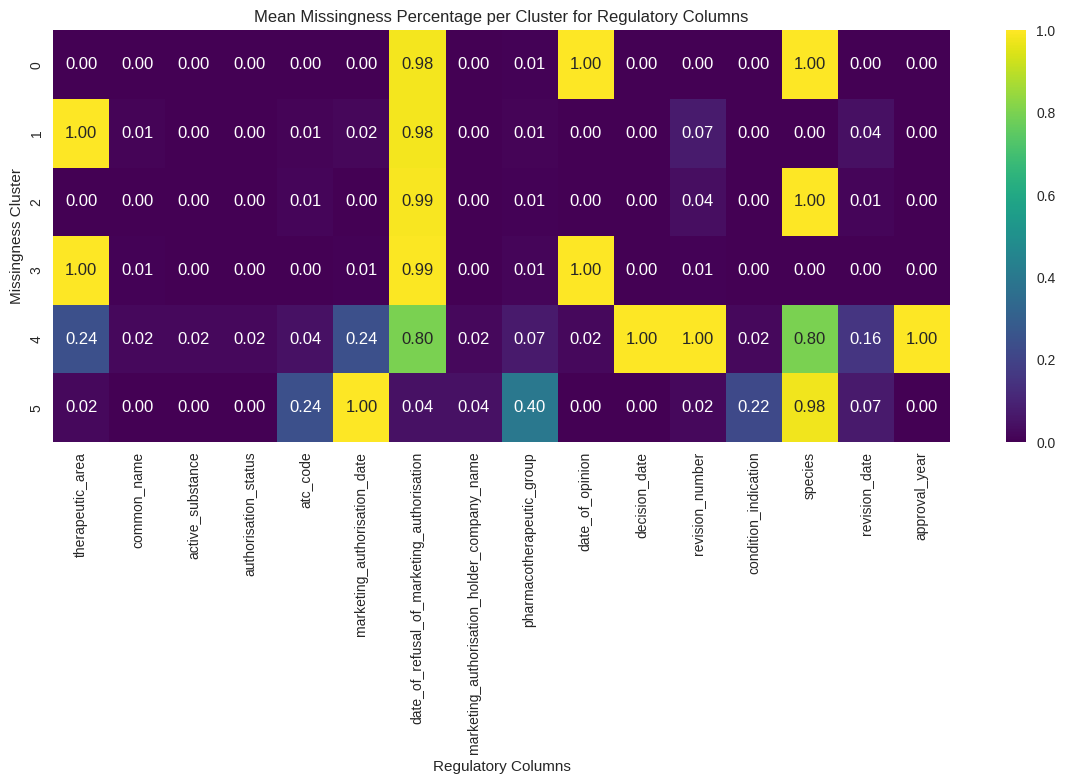

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(mean_missingness_per_cluster, annot=True, cmap='viridis', fmt='.2f')
plt.title('Mean Missingness Percentage per Cluster for Regulatory Columns')
plt.xlabel('Regulatory Columns')
plt.ylabel('Missingness Cluster')
plt.tight_layout()
plt.show()

# M4 - Refinement

Heirarchical Clustering

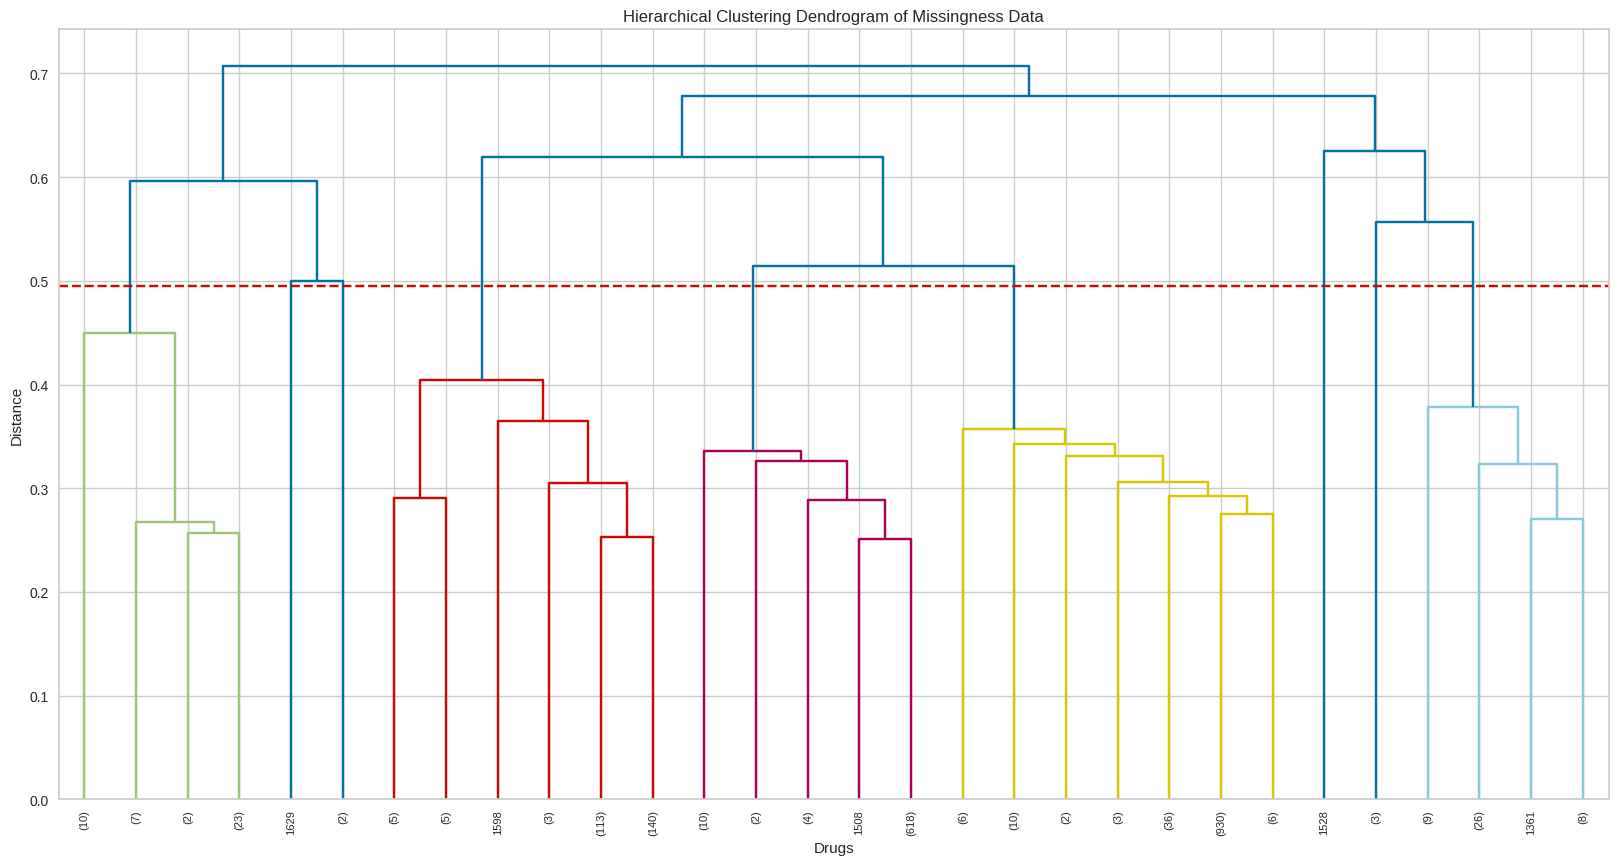

In [ ]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
import numpy as np
import matplotlib.pyplot as plt
import sys

# Perform hierarchical clustering on the preprocessed numerical data
Z = linkage(missingness_df, method='average', metric='jaccard')

# Plot the dendrogram, truncating for readability with large datasets
plt.figure(figsize=(20, 10))
dendrogram(Z,
           leaf_rotation=90.,  # rotates the x axis labels
           leaf_font_size=8.,  # font size for the x axis labels
           truncate_mode='lastp',  # show only the last p merged clusters
           p=30,  # show only the last 30 merged clusters
           show_leaf_counts=True,
           color_threshold=0.7 * max(Z[:,2]) # color based on a threshold
          )
#horizontal line at optimal number of clusters
plt.axhline(y=0.7 * max(Z[:,2]), color='r', linestyle='--')
plt.title('Hierarchical Clustering Dendrogram of Missingness Data')
plt.xlabel('Drugs')
plt.ylabel('Distance')
plt.show()

In [ ]:
n_clusters = 3


clusters = fcluster(Z, n_clusters, criterion='maxclust')

drugs['hac_cluster'] = clusters
missingness_df['hac_cluster'] = clusters

# Calculate the mean missingness for each original missing column, grouped by the new 'hac_cluster'
profile = missingness_df.groupby('hac_cluster')[missing_cols].mean()

In [ ]:
profile.var().sort_values(ascending=False)

,0
revision_number,0.325104
decision_date,0.292969
approval_year,0.292969
date_of_refusal_of_marketing_authorisation,0.278206
marketing_authorisation_date,0.270175
date_of_opinion,0.053478
pharmacotherapeutic_group,0.045260
condition_indication,0.015020
revision_date,0.011311
atc_code,0.009275


In [ ]:
drugs.groupby('hac_cluster')['approval_year'].agg(['mean','median','count'])

,mean,median,count
hac_cluster,,,
1,2012.355556,2012.0,45
2,2020.149868,2022.0,1895
3,2022.000000,2022.0,3


In [ ]:
drugs.groupby('hac_cluster')['authorisation_status'].value_counts(normalize=True)

hac_cluster  authorisation_status
1            refused                 1.000000
2            authorised              0.810554
             withdrawn               0.187863
             refused                 0.001583
3            authorised              0.787234
             refused                 0.191489
             withdrawn               0.021277
Name: proportion, dtype: float64

In [ ]:
drugs.groupby('hac_cluster')['therapeutic_area'].value_counts(normalize=True)

hac_cluster  therapeutic_area                                  
1            Alzheimer Disease                                     0.047619
             Crohn Disease                                         0.047619
             Depressive Disorder, Major                            0.047619
             Fibromyalgia                                          0.047619
             Lymphoma, Non-Hodgkin                                 0.047619
                                                                     ...   
3            Progeria;  Laminopathies                              0.027027
             Psoriasis                                             0.027027
             Sleep Initiation and Maintenance Disorders            0.027027
             Substance Withdrawal Syndrome;  Alcohol Abstinence    0.027027
             Wet Macular Degeneration                              0.027027
Name: proportion, Length: 715, dtype: float64

In [ ]:
drugs.groupby('hac_cluster')['species'].value_counts(normalize=True)

hac_cluster  species            
1            Cats                   0.333333
             Dogs                   0.333333
             Horses                 0.333333
2            Dogs                   0.250936
             Cats                   0.097378
                                      ...   
3            Cats                   0.111111
             Cats; Dogs; Ferrets    0.111111
             Chicken                0.111111
             Pigs                   0.111111
             Rabbits                0.111111
Name: proportion, Length: 68, dtype: float64

In [ ]:
drugs.groupby('hac_cluster')['revision_number'].mean()

,revision_number
hac_cluster,
1,0.000000
2,13.857066
3,NaN


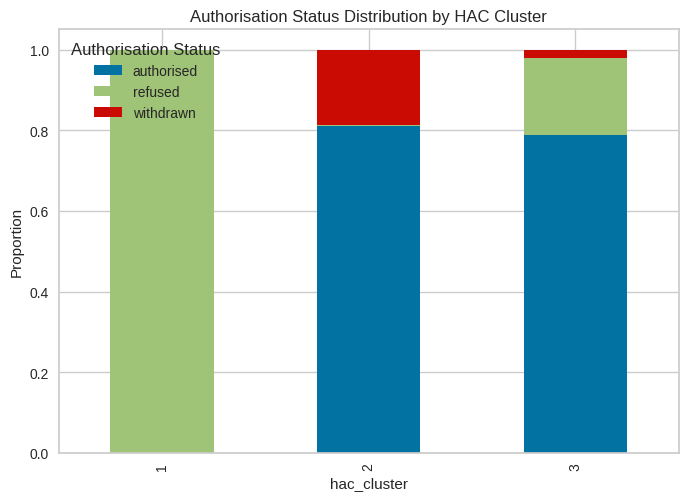

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

status_dist = (
    drugs.groupby('hac_cluster')['authorisation_status']
      .value_counts(normalize=True)
      .unstack()
)

status_dist.plot(kind='bar', stacked=True)
plt.title('Authorisation Status Distribution by HAC Cluster')
plt.ylabel('Proportion')
plt.legend(title='Authorisation Status')
plt.show()

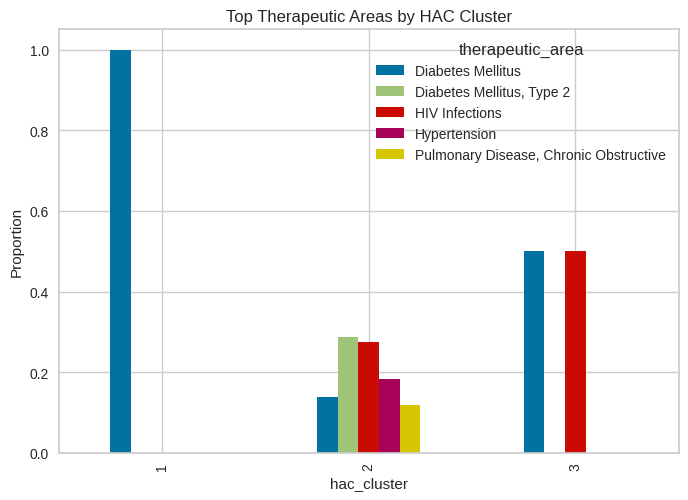

In [488]:
top_areas = drugs['therapeutic_area'].value_counts().head(5).index
filtered = drugs[drugs['therapeutic_area'].isin(top_areas)]

area_dist = (
    filtered.groupby('hac_cluster')['therapeutic_area']
    .value_counts(normalize=True)
    .unstack()
)

area_dist.plot(kind='bar', stacked=True)
plt.title('Top Therapeutic Areas by HAC Cluster')
plt.ylabel('Proportion')
plt.show()

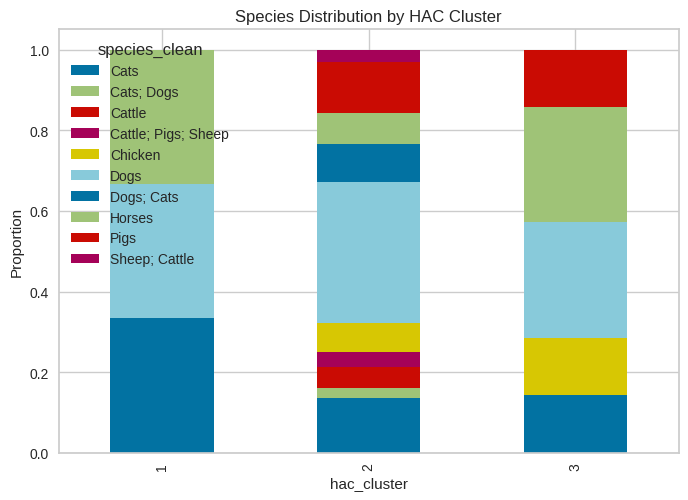

In [507]:
top_species = drugs['species'].value_counts().nlargest(10).index
drugs['species_clean'] = drugs['species'].where(drugs['species'].isin(top_species)) #removed other becuase it dominated the graph

species_dist = (
    drugs.groupby('hac_cluster')['species_clean']
      .value_counts(normalize=True)
      .unstack()
)

species_dist.plot(kind='bar', stacked = True)
plt.title('Species Distribution by HAC Cluster')
plt.ylabel('Proportion')
plt.show()

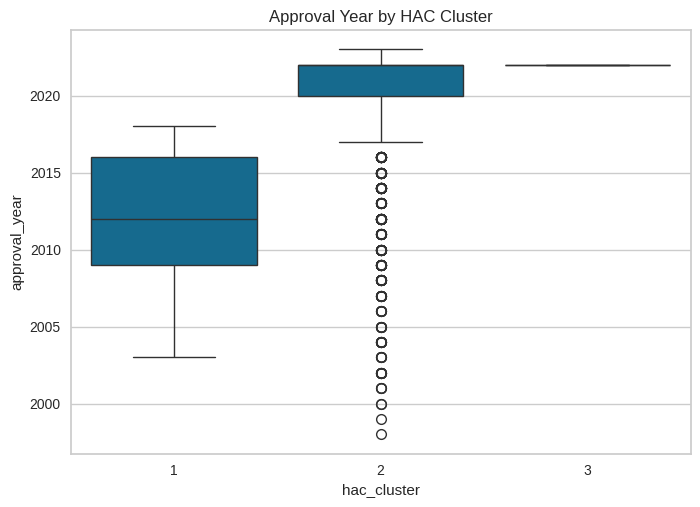

In [ ]:
sns.boxplot(x='hac_cluster', y='approval_year', data=drugs)
plt.title('Approval Year by HAC Cluster')
plt.show()

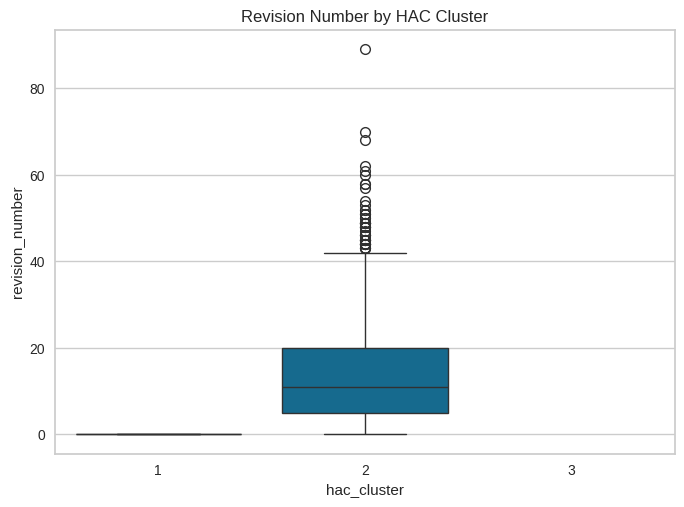

In [ ]:
sns.boxplot(x='hac_cluster', y='revision_number', data=drugs)
plt.title('Revision Number by HAC Cluster')
plt.show()

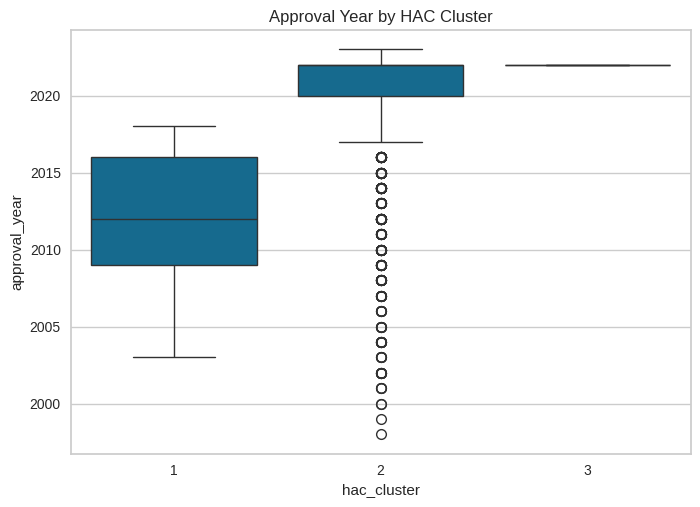

In [ ]:
sns.boxplot(x='hac_cluster', y='approval_year', data=drugs)
plt.title('Approval Year by HAC Cluster')
plt.show()

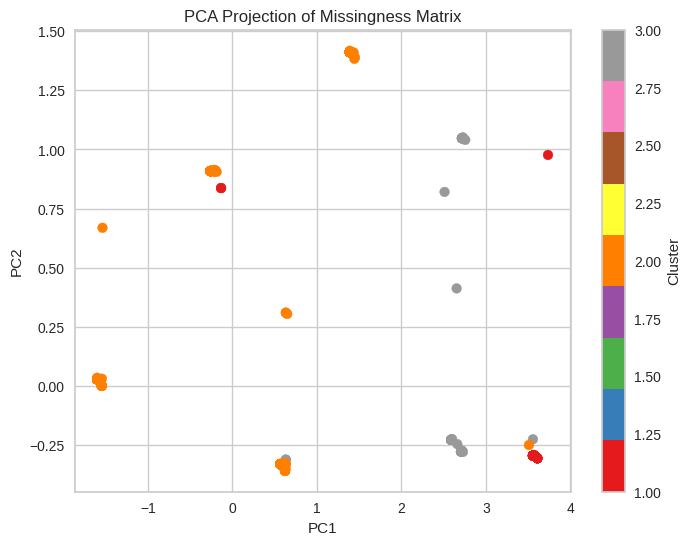

In [ ]:
from sklearn.decomposition import PCA

X = missingness_df.values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=missingness_df['hac_cluster'], cmap='Set1')#whether using drugs or missingness here it doesnt matter
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection of Missingness Matrix')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
print(pca.explained_variance_ratio_)

[0.72088399 0.11877162]


Text(0.5, 1.0, 'Cluster Separation via PCA (K-Means)')

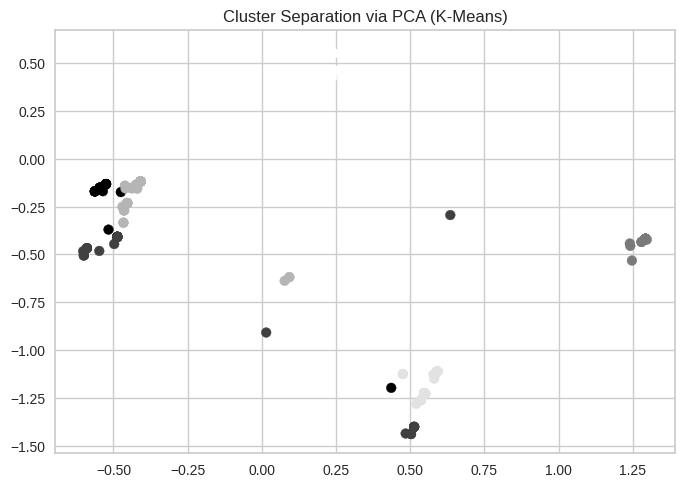

In [ ]:
# Visualize separation for K-Means
pca = PCA(n_components=2)
components = pca.fit_transform(missingness_df.drop('missingness_cluster_kmean', axis=1))
plt.scatter(components[:,0], components[:,1], c=drugs['missingness_cluster_kmean'])
plt.title("Cluster Separation via PCA (K-Means)")

Text(0.5, 1.0, 'Cluster Separation via PCA (Hierarchical Labels)')

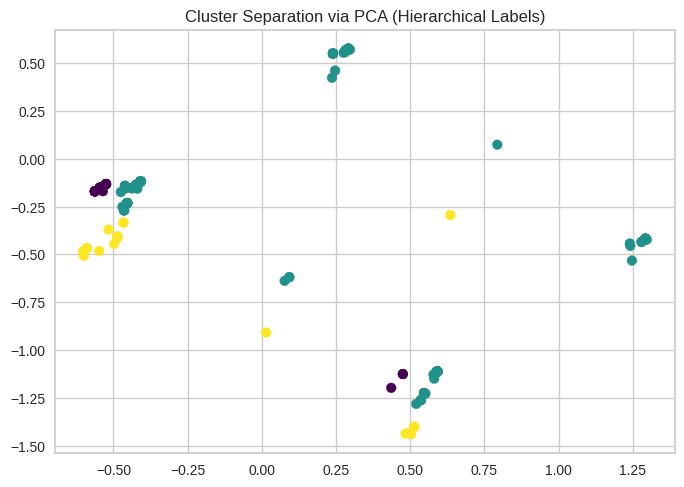

In [ ]:
# To visualize HAC instead of KMeans:
plt.scatter(components[:,0], components[:,1], c=missingness_df['hac_cluster'], cmap='viridis')
plt.title("Cluster Separation via PCA (Hierarchical Labels)")

In [ ]:
from scipy import stats
# used ChatGPT here since we didn't learn Kruskal statistics.

# 1. Create lists of values for each cluster, but ONLY if the cluster has valid year data
# We check if the resulting series is not empty after dropping NaNs
groups = [drugs[drugs['missingness_cluster_kmean'] == i]['approval_year'].dropna()
          for i in drugs['missingness_cluster_kmean'].unique()
          if not drugs[drugs['missingness_cluster_kmean'] == i]['approval_year'].dropna().empty]

# 2. Run the test on the valid groups
h_stat, p_val = stats.kruskal(*groups)

print('K-Means Stats')
print(f"H-statistic: {h_stat:.3f}")
print(f"P-value: {p_val:.3e}")

K-Means Stats
H-statistic: 573.188
P-value: 9.832e-123


In [ ]:
from scipy import stats

# 1. Create lists of values for each cluster, but ONLY if the cluster has valid year data
# We check if the resulting series is not empty after dropping NaNs
groups = [drugs[drugs['hac_cluster'] == i]['approval_year'].dropna()
          for i in drugs['hac_cluster'].unique()
          if not drugs[drugs['hac_cluster'] == i]['approval_year'].dropna().empty]

# 2. Run the test on the valid groups
h_stat, p_val = stats.kruskal(*groups)

print('HAC Stats')
print(f"H-statistic: {h_stat:.3f}")
print(f"P-value: {p_val:.3e}")

HAC Stats
H-statistic: 102.455
P-value: 5.652e-23


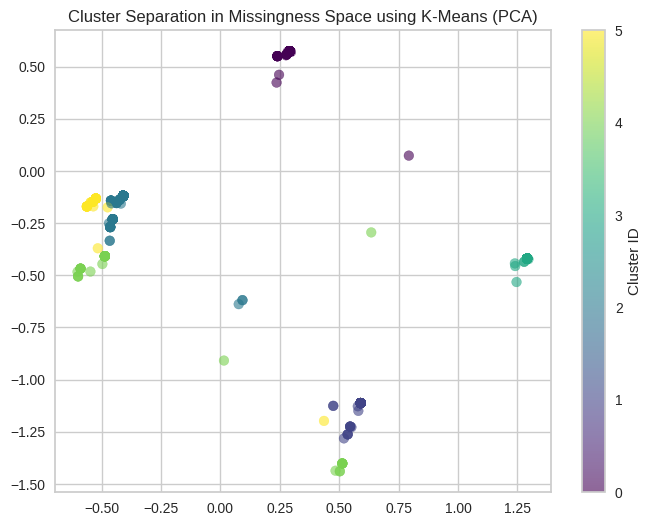

In [ ]:
# Reduce the 16 missingness columns to 2 dimensions for visualization
pca = PCA(n_components=2)
components = pca.fit_transform(missingness_df.drop('missingness_cluster_kmean', axis=1))

plt.figure(figsize=(8, 6))
plt.scatter(components[:, 0], components[:, 1], c=drugs['missingness_cluster_kmean'], cmap='viridis', alpha=0.6)
plt.title("Cluster Separation in Missingness Space using K-Means (PCA)")
plt.colorbar(label='Cluster ID')
plt.show()

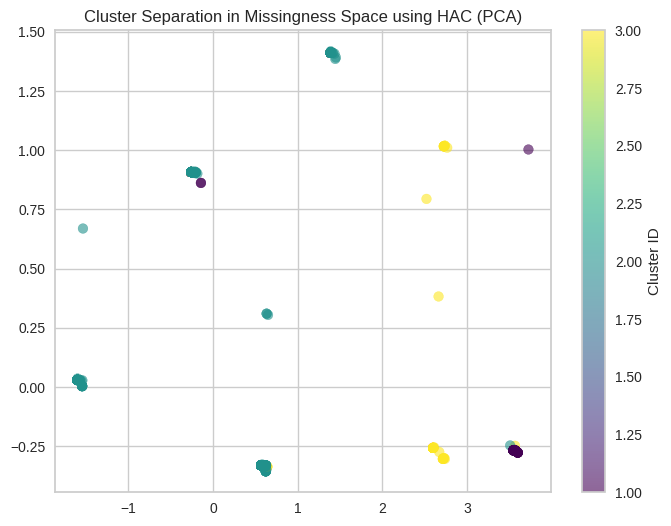

In [ ]:
# Reduce the 16 missingness columns to 2 dimensions for visualization
pca = PCA(n_components=2)
components = pca.fit_transform(missingness_df.drop('hac_cluster', axis=1))

plt.figure(figsize=(8, 6))
plt.scatter(components[:, 0], components[:, 1], c=drugs['hac_cluster'], cmap='viridis', alpha=0.6)
plt.title("Cluster Separation in Missingness Space using HAC (PCA)")
plt.colorbar(label='Cluster ID')
plt.show()

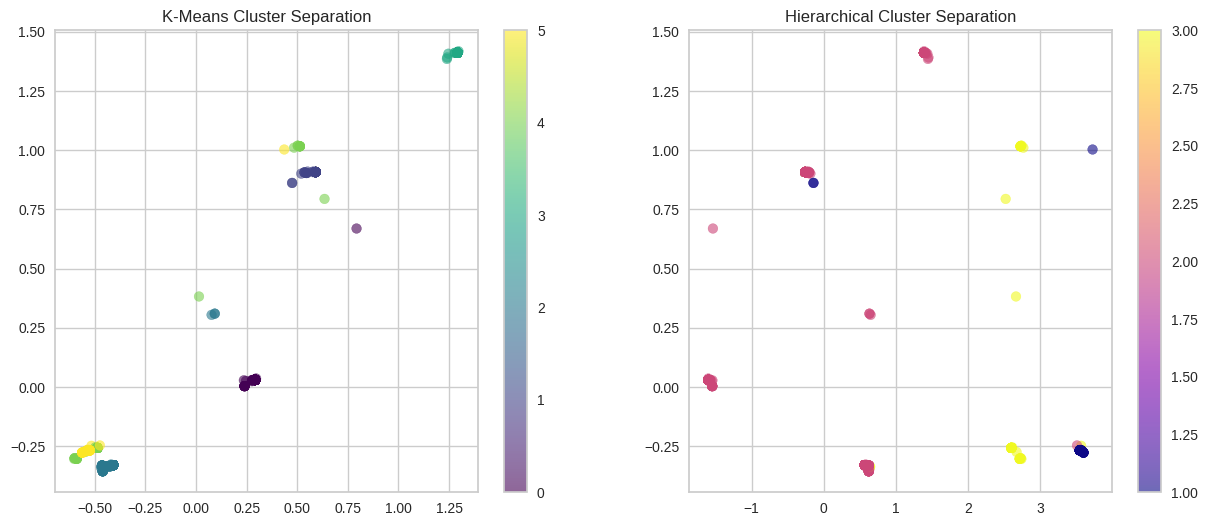

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensionality for visualization
pca = PCA(n_components=2)
components_k = pca.fit_transform(missingness_df.drop('missingness_cluster_kmean', axis=1))
components_h = pca.fit_transform(missingness_df.drop('hac_cluster', axis=1))

# Plot both side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: K-Means
scatter1 = ax1.scatter(components_k[:, 0], components[:, 1], c=drugs['missingness_cluster_kmean'], cmap='viridis', alpha=0.6)
ax1.set_title("K-Means Cluster Separation")
fig.colorbar(scatter1, ax=ax1)

# Plot 2: Hierarchical (HAC)
scatter2 = ax2.scatter(components_h[:, 0], components[:, 1], c=drugs['hac_cluster'], cmap='plasma', alpha=0.6)
ax2.set_title("Hierarchical Cluster Separation")
fig.colorbar(scatter2, ax=ax2)

plt.show()

In [ ]:
missingness_df['missing_rate'] = missingness_df[missing_cols].mean(axis=1)
missingness_df.groupby('hac_cluster')['missing_rate'].agg(['mean','median','std'])

,mean,median,std
hac_cluster,,,
1,0.181944,0.1250,0.073978
2,0.153397,0.1250,0.034461
3,0.342448,0.3125,0.093852


In [ ]:
print('approval year', missingness_df.groupby('hac_cluster')['approval_year'].mean().var(),
'Missing Rate',missingness_df.groupby('hac_cluster')['missing_rate'].mean().var(),
'revision number',missingness_df.groupby('hac_cluster')['revision_number'].mean().var(),
'species',missingness_df.groupby('hac_cluster')['species'].mean().var())

approval year 0.29296875 Missing Rate 0.010386087964333462 revision number 0.32510392807995864 species 0.003713780305749392
